# ISO 20414:2020 — Test 13: Flow rate, density and walking speed in a corridor

A 2 m x 60 m corridor (area 120 m^2) in three zones (ISO 20414:2020 Table 14). 60/120/240/360/480 occupants give initial densities of 0.5/1.0/2.0/3.0/4.0 p/m^2. Walking speed in zone 2 is measured between line A (x = 20) and line B (x = 40). The expected result is the classic speed-down / flow-hump fundamental diagram.

In [1]:
from datetime import datetime

print(f"Executed on {datetime.now().astimezone().strftime('%d %B %Y, %H:%M %Z')}")

Executed on 08 July 2026, 10:06 CEST


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from jupedsim_scenarios import load_scenario, run_scenario

In [3]:
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "#f7f7f5",
        "axes.edgecolor": "#3a3a3a",
        "axes.labelcolor": "#1d1d1d",
        "axes.titleweight": "bold",
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 11,
        "figure.figsize": (8, 5),
    }
)

In [4]:
import json
import tempfile

from scenario_builders.iso13_corridor_fd import (
    CORRIDOR_WKT,
    DENSITY_CASES,
    build_raw_scenario,
    measure_zone2,
)

## Scenario check — geometry and trajectories

Confirm the simulated layout: a 2 m x 60 m corridor divided into three zones by line A (x = 20) and line B (x = 40); occupants (here the n = 120 case) walk left to right to the exit. Zone 2, between the lines, is where speed, density, and flow are measured.

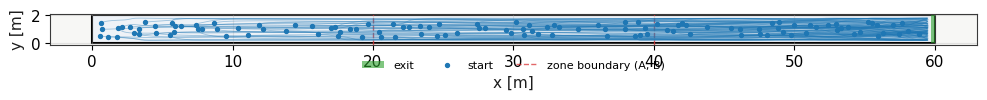

1

In [5]:
_raw = build_raw_scenario(120)
with tempfile.TemporaryDirectory() as _d:
    _p = Path(_d)
    (_p / "config.json").write_text(json.dumps(_raw, indent=2), encoding="utf-8")
    (_p / "geometry.wkt").write_text(CORRIDOR_WKT, encoding="utf-8")
    scen = load_scenario(str(_p))
    _res = run_scenario(scen, seed=42)
tdf = _res.trajectory_dataframe()
poly = scen.walkable_polygon
fig, ax = plt.subplots(figsize=(10, 2.4))
gx, gy = poly.exterior.xy
ax.fill(gx, gy, facecolor="#eef2f7", edgecolor="k", lw=1.5, zorder=0)
for interior in poly.interiors:
    ix, iy = interior.xy
    ax.fill(ix, iy, facecolor="white", edgecolor="k", lw=1.0, zorder=1)
for z in scen.zones.values():
    zx = [c[0] for c in z["coordinates"]]
    zy = [c[1] for c in z["coordinates"]]
    ax.fill(
        zx,
        zy,
        facecolor="tab:orange",
        alpha=0.18,
        edgecolor="tab:orange",
        zorder=1,
        label=f"speed-factor {z.get('speed_factor')} zone",
    )
for e in scen.exits.values():
    ex = [c[0] for c in e["coordinates"]]
    ey = [c[1] for c in e["coordinates"]]
    ax.fill(ex, ey, facecolor="tab:green", alpha=0.6, zorder=2, label="exit")
for _, sub in tdf.sort_values(["id", "frame"]).groupby("id"):
    ax.plot(sub.x, sub.y, color="tab:blue", lw=0.6, alpha=0.4, zorder=3)
starts = tdf.sort_values(["id", "frame"]).groupby("id").first()
ax.scatter(starts.x, starts.y, s=8, color="tab:blue", zorder=4, label="start")
ax.axvline(20.0, color="tab:red", ls="--", lw=1.0, alpha=0.7, label="zone boundary (A, B)")
ax.axvline(40.0, color="tab:red", ls="--", lw=1.0, alpha=0.7)
handles, labels = ax.get_legend_handles_labels()
uniq = dict(zip(labels, handles))
ax.legend(
    uniq.values(),
    uniq.keys(),
    fontsize=8,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=3,
    frameon=False,
)
ax.set_aspect("equal")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
plt.tight_layout()
plt.show()
_res.cleanup()

## Sweep occupant counts / densities

In [6]:
rows = []
for n, rho0 in DENSITY_CASES.items():
    raw = build_raw_scenario(n)
    with tempfile.TemporaryDirectory() as d:
        p = Path(d)
        (p / "config.json").write_text(json.dumps(raw, indent=2), encoding="utf-8")
        (p / "geometry.wkt").write_text(CORRIDOR_WKT, encoding="utf-8")
        scenario = load_scenario(str(p))
        r = run_scenario(scenario, seed=42)
        m = measure_zone2(r.trajectory_dataframe(), r.frame_rate)
        m["n_agents"] = n
        m["initial_density"] = rho0
        rows.append(m)
        r.cleanup()
fd = pd.DataFrame(rows)
fd

,mean_speed_zone2_m_s,n_speed_samples,peak_density_zone2_p_m2,mean_density_zone2_p_m2,flow_line_b_p_s,specific_flow_line_b_p_m_s,n_agents,initial_density
0,1.919989,41,0.625,0.419860,1.072386,0.536193,60,0.5
1,2.736204,80,1.075,0.748647,1.880952,0.940476,120,1.0
2,3.106481,162,1.950,1.354968,2.543444,1.271722,240,2.0
3,2.010388,241,3.000,2.234647,2.492212,1.246106,360,3.0
4,1.065875,324,4.175,3.157928,2.498067,1.249033,480,4.0


## Fundamental diagram (speed-density and flow-density)

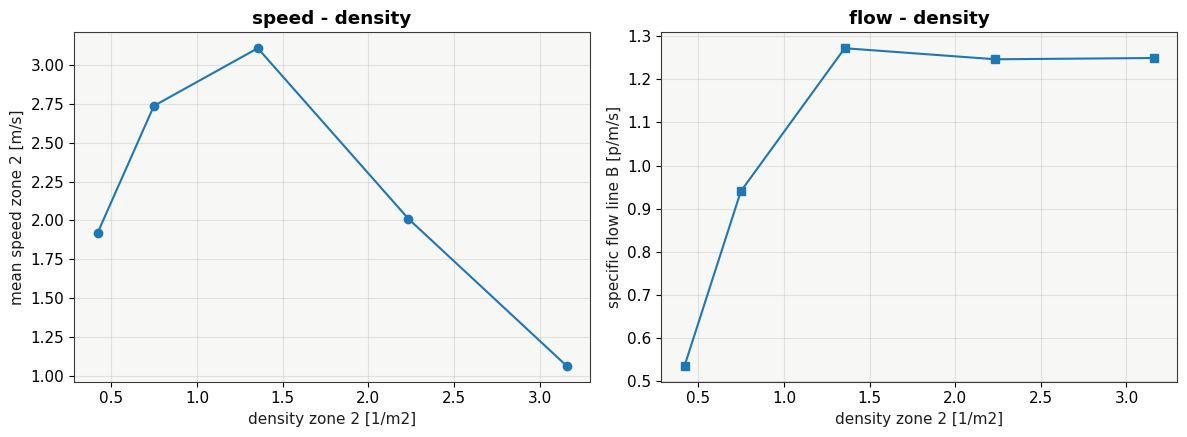

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ax1.plot(fd["mean_density_zone2_p_m2"], fd["mean_speed_zone2_m_s"], "o-")
ax1.set_xlabel("density zone 2 [1/m2]")
ax1.set_ylabel("mean speed zone 2 [m/s]")
ax1.set_title("speed - density")
ax2.plot(fd["mean_density_zone2_p_m2"], fd["specific_flow_line_b_p_m_s"], "s-")
ax2.set_xlabel("density zone 2 [1/m2]")
ax2.set_ylabel("specific flow line B [p/m/s]")
ax2.set_title("flow - density")
fig.tight_layout()
plt.show()

## Acceptance — FAIL

ISO 20414:2020 Test 13 expects the zone-2 speed-density (and flow-density) relationship to be produced and **compared with the model's underlying assumptions**. Here it contradicts them: every measured mean zone-2 speed (1.9–3.1 m/s) **exceeds the 1.0 m/s free speed assigned to the crowd**, and the curve rises then falls instead of decreasing monotonically. At high density (4 p/m², 480 agents) the corridor visibly jams. The model therefore does **not** demonstrate a valid fundamental diagram and **fails** ISO Test 13.

(The earlier "negative speed-density slope" check passed only as a linear-fit artifact over these non-physical values. CollisionFreeSpeedModel does not reproduce empirical crowd-flow fundamental diagrams.)

In [8]:
free_speed = 1.0
speed = fd["mean_speed_zone2_m_s"].to_numpy()
over = fd.loc[speed > free_speed + 0.05, "initial_density"].tolist()
print("mean zone-2 speed [m/s]:", [round(float(v), 3) for v in speed])
print(f"assigned free speed v0 = {free_speed} m/s")
verdict = "FAIL" if over else "PASS"
print(f"\nRESULT: {verdict} - ISO 20414:2020 Test 13 (corridor fundamental diagram)")
if over:
    print(f"Zone-2 speed exceeds the {free_speed} m/s free speed at densities {over} p/m2,")
    print("non-monotonic in density: the speed-density relationship is non-physical")
    print("and contradicts the model's own assumptions. Documented CFSM limit.")

mean zone-2 speed [m/s]: [1.92, 2.736, 3.106, 2.01, 1.066]
assigned free speed v0 = 1.0 m/s

RESULT: FAIL - ISO 20414:2020 Test 13 (corridor fundamental diagram)
Zone-2 speed exceeds the 1.0 m/s free speed at densities [0.5, 1.0, 2.0, 3.0, 4.0] p/m2,
non-monotonic in density: the speed-density relationship is non-physical
and contradicts the model's own assumptions. Documented CFSM limit.
